# BioSeek Final Notebook
**Project Application Demo Video:** https://www.youtube.com/watch?v=qsRDyH1-u4E
 
This notebook is a walk-through of **BioSeek**, a biomedical retrieval and data mining application.

The project compares four retrieval methods over biomedical literature:

- **TF-IDF**
- **BM25**
- **Dense retrieval** using sentence-transformer embeddings
- **Hybrid retrieval** that fuses lexical and semantic evidence

The core research question is:

> **How do different retrieval methods affect both the relevance and the diversity or structure of biomedical information retrieved from PubMed?**


## Notebook Contents

This notebook is organized to mirror the user-facing web application I developed.

1. I start with the **problem motivation** and dataset design.
2. I show how the **backend retrieval system** is built and what the app exposes.
3. I run a **representative app-style query walkthrough** using the same backend services the web app calls.
4. I summarize the **benchmark evaluation results** on the unified BioASQ-PubMed dataset.
5. I show the deeper analysis layers: **query-type analysis, clustering, and diversity**.
6. I end with **conclusions, limitations, future directions, and reproducibility notes**.

Throughout the notebook, I have pointed to the backend scripts and service modules that generated each artifact so it is clear what code is being reused and where the key parameters are.


## Motivation Of The Project

Biomedical research is growing with millions of papers available in repositories like PubMed. While search systems are designed to retrieve *relevant* documents, relevance alone does not capture how useful a retrieval system is.

Two systems can achieve similar scores on standard metrics like Precision or nDCG, yet expose **very different subsets of the literature**. Lexical methods usually return narrowly focused results centered on exact terminology, while semantic methods may surface a broader set of related concepts, offering a more comprehensive view of the topic.

BioSeek was built to study this gap directly. Instead of evaluating retrieval methods only by how well they rank relevant documents, this project also asks:

- Which methods retrieve the most relevant documents?
- Which methods surface **broader or narrower evidence landscapes**?
- How do different methods behave across **different types of biomedical queries**?
- Can a hybrid approach effectively balance **precision with semantic flexibility**?

To answer these questions, the project combines a **benchmark evaluation pipeline** with an **interactive exploration system**. This allows not only quantitative comparison of retrieval performance, but also qualitative analysis of how different methods structure and present biomedical knowledge.

The goal is to move beyond “what is retrieved” and understand **how retrieval methods shape the information we see**.


## Research Questions

This project studies how different retrieval methods influence both the relevance and the structure of biomedical information.

**Primary Question:**

> How do different retrieval methods affect both the relevance and the diversity or structure of biomedical information retrieved from PubMed?

**Sub-Questions:**

1. Which retrieval method performs best under standard IR metrics such as Precision@k, Recall@k, MRR, and nDCG?
2. Do higher-performing methods also provide broader and more diverse evidence coverage?
3. How do lexical, dense, and hybrid retrieval methods behave differently across query types?
4. How do these methods differ in how retrieved results are structured (e.g., clustering, grouping)?


## Retrieval Methods Compared

BioSeek compares four retrieval strategies:

* **TF-IDF**: A lexical baseline based on weighted term frequency.
* **BM25**: A probabilistic ranking model optimized for keyword-based retrieval.
* **Dense Retrieval**: A semantic approach that captures conceptual similarity using sentence-transformer embeddings and FAISS.
* **Hybrid Retrieval**: A weighted combination of lexical and semantic signals to balance precision and recall.

The implementation for these methods lives in the backend retriever modules:

- `backend/app/retrieval/tfidf.py`
- `backend/app/retrieval/bm25.py`
- `backend/app/retrieval/dense.py`
- `backend/app/retrieval/hybrid.py`
- `backend/app/retrieval/service.py` orchestrates method selection and caching.

This comparison is important because biomedical queries often involve both exact terminology and semantic variation.


In [1]:
import json
import os
import platform
import sys
import warnings
from importlib.metadata import PackageNotFoundError, version
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

os.environ.setdefault("ARROW_USER_SIMD_LEVEL", "none")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

warnings.filterwarnings("ignore", message="Trying to unpickle estimator")
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "backend").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the BioSeek project root from the current notebook location.")

PROJECT_ROOT = find_project_root()
BACKEND_PATH = PROJECT_ROOT / "backend"
if str(BACKEND_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_PATH))

# These are the same backend services used by the FastAPI app. Importing them here
# keeps the notebook aligned with the real project implementation instead of a separate demo path.
from app.retrieval.service import get_retrieval_service
from app.services.ai_polish_service import get_ai_polish_service
from app.services.analysis_service import get_analysis_service
from app.services.query_service import get_query_service
from app.services.search_service import get_search_service

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Offline dense mode:", os.environ.get("HF_HUB_OFFLINE"), os.environ.get("TRANSFORMERS_OFFLINE"))


import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


Project root: /Users/gurmeharsibal/Desktop/CSCE676_Project_BiomedicalTextMining-main
Python: 3.9.6
Platform: macOS-15.5-arm64-arm-64bit
Offline dense mode: 1 1


## Load The Final Project Artifacts

The notebook uses the same processed artifacts and backend used in the web app.

Dataset & Evaluation Files
Due to the large size of the processed dataset and evaluation artifacts, they are not included directly in this repository.

You can download them from the following link:
https://drive.google.com/drive/folders/1UlYyxLGghrMv3ZLSC2R-61kkyq0tsCrl


The key resources loaded below are produced by these scripts and modules:

- `scripts/join_pubmed_bioasq.py`: builds the unified BioASQ-PubMed evaluation dataset.
- `scripts/build_retrieval_indexes.py`: builds TF-IDF, BM25, and dense indexes through the backend retrieval service.
- `scripts/evaluate_retrieval.py`: computes the benchmark metrics saved under `eval/results/unified/`.
- `scripts/analyze_query_types.py`: produces the query-bucket outputs.
- `scripts/analyze_diversity.py`: produces the diversity and structure outputs.
- `backend/app/services/*.py`: provide the same service layer the web app calls.

So even though I am loading saved artifacts directly here for efficiency, each table still maps back to a concrete backend script in the repository.


In [2]:
# These tables and JSON files are the final saved artifacts produced by the backend pipeline.
# Loading them here keeps the notebook reproducible without rerunning every expensive step.
bioasq_questions_df = pd.read_parquet(PROJECT_ROOT / "data/processed/bioasq/questions.parquet")
bioasq_relevance_df = pd.read_parquet(PROJECT_ROOT / "data/processed/bioasq/relevance.parquet")
pubmed_subset_df = pd.read_parquet(PROJECT_ROOT / "data/processed/pubmed_subset/docs.parquet")
unified_questions_df = pd.read_parquet(PROJECT_ROOT / "data/processed/unified/questions.parquet")
unified_docs_df = pd.read_parquet(PROJECT_ROOT / "data/processed/unified/docs.parquet")
per_query_metrics_df = pd.read_parquet(PROJECT_ROOT / "eval/results/unified/per_query_metrics.parquet")
per_bucket_metrics_df = pd.read_csv(PROJECT_ROOT / "eval/results/unified/query_type_analysis/per_bucket_metrics.csv")
diversity_metrics_df = pd.read_csv(PROJECT_ROOT / "eval/results/unified/diversity/dense/method_level_diversity.csv")

mapping_report = json.loads((PROJECT_ROOT / "data/processed/unified/mapping_report.json").read_text())
source_report = json.loads((PROJECT_ROOT / "data/processed/pubmed_subset/source_report.json").read_text())
summary_metrics = pd.DataFrame(json.loads((PROJECT_ROOT / "eval/results/unified/summary.json").read_text()))
summary_narrative = json.loads((PROJECT_ROOT / "eval/results/unified/narrative.json").read_text())
frontend_metrics = json.loads((PROJECT_ROOT / "eval/results/unified/frontend_metrics.json").read_text())
bucket_summary = json.loads((PROJECT_ROOT / "eval/results/unified/query_type_analysis/bucket_summary.json").read_text())
diversity_payload = json.loads((PROJECT_ROOT / "eval/results/unified/diversity/dense/diversity_metrics.json").read_text())
best_worst_payload = json.loads((PROJECT_ROOT / "eval/results/unified/best_worst_queries.json").read_text())
settings = json.loads((PROJECT_ROOT / "shared/config/settings.json").read_text())
frontend_shell = json.loads((PROJECT_ROOT / "frontend/public/mock/frontend-shell.json").read_text())

snapshot_df = pd.DataFrame(
    [
        {"artifact": "BioASQ questions", "rows": len(bioasq_questions_df)},
        {"artifact": "BioASQ relevance rows", "rows": len(bioasq_relevance_df)},
        {"artifact": "Curated PubMed subset docs", "rows": len(pubmed_subset_df)},
        {"artifact": "Unified evaluation questions", "rows": len(unified_questions_df)},
        {"artifact": "Unified evaluation docs", "rows": len(unified_docs_df)},
        {"artifact": "Per-query metric rows", "rows": len(per_query_metrics_df)},
    ]
)
display(snapshot_df)


,artifact,rows
0,BioASQ questions,5399
1,BioASQ relevance rows,51897
2,Curated PubMed subset docs,83206
3,Unified evaluation questions,4835
4,Unified evaluation docs,32251
5,Per-query metric rows,19340


The abobe table and the following bar chart shows the scale difference between the raw BioASQ inputs, the curated PubMed corpus, and the smaller unified benchmark used for evaluation.


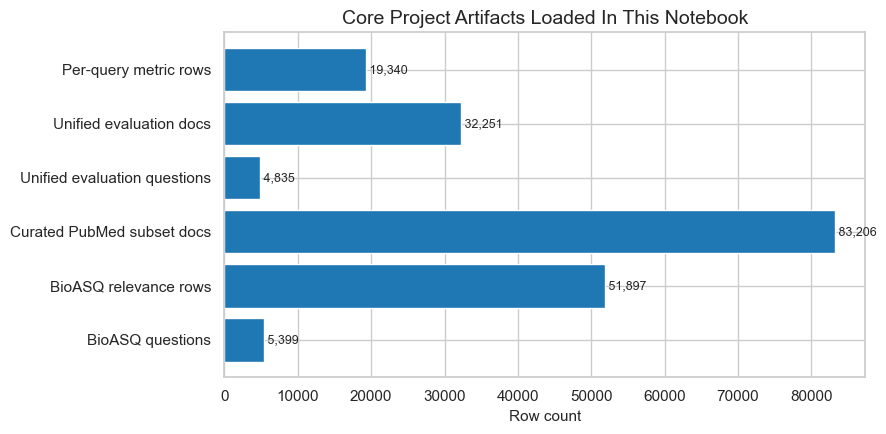

In [3]:
artifact_plot_df = snapshot_df.copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(artifact_plot_df['artifact'], artifact_plot_df['rows'], color='#1f77b4')
ax.set_title('Core Project Artifacts Loaded In This Notebook')
ax.set_xlabel('Row count')
ax.set_ylabel('')
for i, value in enumerate(artifact_plot_df['rows']):
    ax.text(value, i, f' {value:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## Dataset Design

The most important data-engineering choice in BioSeek is the **exact PMID join** between BioASQ relevance judgments and the curated PubMed subset.

This design choice matters because:

- no fuzzy title matching,
- no heuristic document linking,
- no accidental relevance inflation.

A document only counts as relevant if the PubMed identifier matches exactly. 


### Dataset Design Insight

The PMID-based matching reduces dataset size but improves evaluation quality.

Only documents present in both the BioASQ relevance set and the curated PubMed corpus are evaluated. This avoids approximate matching and ensures that all relevance judgments are reliable.


### Final Benchmark Dataset Construction

The next tables summarize how the final benchmark dataset was constructed after joining BioASQ supervision with the curated PubMed subset.

The key point is that the benchmark is smaller than the raw sources because I keep only exact PMID matches. That makes the evaluation more reliable, even though it reduces coverage.


In [4]:
dataset_story_df = pd.DataFrame(
    [
        {"metric": "Original BioASQ questions", "value": mapping_report["total_bioasq_questions"]},
        {"metric": "Original unique BioASQ PMIDs", "value": mapping_report["total_bioasq_unique_pmids"]},
        {"metric": "Curated PubMed subset docs", "value": mapping_report["total_docs_in_curated_pubmed_subset"]},
        {"metric": "Mapped relevant docs in unified corpus", "value": mapping_report["total_mapped_relevant_docs"]},
        {"metric": "Mapped qrels kept", "value": mapping_report["total_mapped_qrels"]},
        {"metric": "Surviving benchmark queries", "value": mapping_report["number_of_surviving_queries"]},
        {"metric": "Avg. relevant docs per surviving query", "value": mapping_report["average_relevant_docs_per_surviving_query"]},
        {"metric": "% of BioASQ relevant PMIDs found", "value": mapping_report["percentage_of_bioasq_relevant_pmids_found_in_corpus"]},
    ]
)
display(dataset_story_df)

source_df = pd.DataFrame(
    [
        {"field": "Source dataset", "value": source_report.get("dataset")},
        {"field": "Source file", "value": source_report.get("file")},
        {"field": "Join key", "value": settings["datasets"]["join_key"]},
        {"field": "Exact PMID join only", "value": mapping_report["exact_pmid_join_only"]},
    ]
)
display(source_df)


,metric,value
0,Original BioASQ questions,5399.0000
1,Original unique BioASQ PMIDs,49045.0000
2,Curated PubMed subset docs,83206.0000
3,Mapped relevant docs in unified corpus,32251.0000
4,Mapped qrels kept,34052.0000
5,Surviving benchmark queries,4835.0000
6,Avg. relevant docs per surviving query,7.0428
7,% of BioASQ relevant PMIDs found,65.7580


,field,value
0,Source dataset,jmhb/pubmed_bioasq_2022
1,Source file,data/allMeSH_2022.parquet
2,Join key,PMID
3,Exact PMID join only,True


This plot visualizes the benchmark-construction tradeoff: a large raw source collection is narrowed into a smaller but more reliable evaluation set.


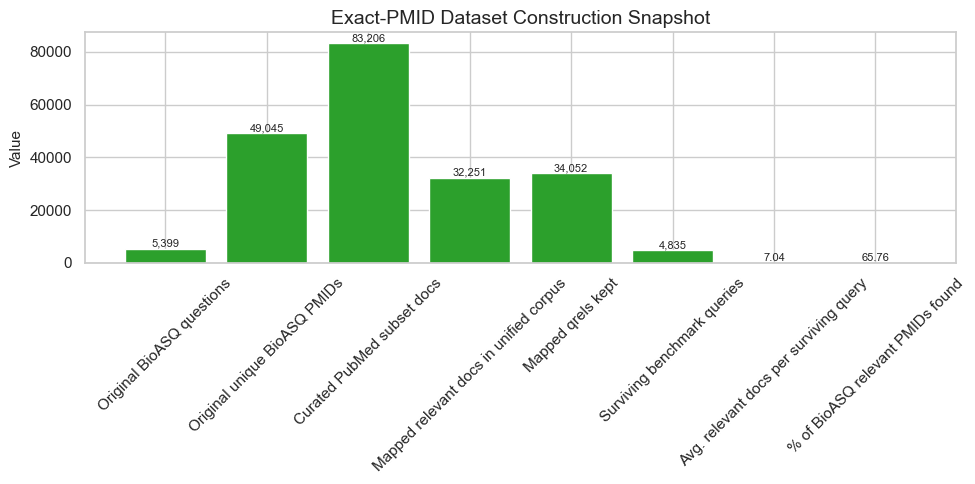

In [5]:
mapping_plot_df = dataset_story_df.copy()
mapping_plot_df['value_num'] = pd.to_numeric(mapping_plot_df['value'], errors='coerce')
plot_ready = mapping_plot_df.dropna(subset=['value_num']).copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_ready['metric'], plot_ready['value_num'], color='#2ca02c')
ax.set_title('Exact-PMID Dataset Construction Snapshot')
ax.set_ylabel('Value')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
for idx, value in enumerate(plot_ready['value_num']):
    label = f'{value:,.0f}' if value >= 100 else f'{value:.2f}'
    ax.text(idx, value, label, ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## How The Web App Maps Onto The Analysis

BioSeek is also implemented as a web application. Its main job is to expose the retrieval system and clustering analyses clearly.

The app is primarily a frontend on top of the same final dataset and backend services used in this notebook.


### Web App to Noteboook Mapping

This table maps each visible web-app feature to the evidence shown later in the notebook. It clarifies that the app is mainly a presentation layer over the same retrieval and analysis pipeline documented here.


In [6]:
app_features_df = pd.DataFrame(
    [
        {"web app capability": "Search tab", "what it demonstrates": "Single-query retrieval over the curated PubMed subset", "notebook evidence": "Live query walkthrough below"},
        {"web app capability": "Method comparison", "what it demonstrates": "How TF-IDF, BM25, dense, and hybrid rank differently", "notebook evidence": "Top-result comparison and overlap table"},
        {"web app capability": "Topic clustering", "what it demonstrates": "How returned documents group into themes", "notebook evidence": "Hybrid cluster summary"},
        {"web app capability": "AI polish", "what it demonstrates": "Optional heuristics for rewrites and match explanations", "notebook evidence": "AI polish output table"},
        {"web app capability": "Evaluation view", "what it demonstrates": "Overall benchmark metrics and query-type findings", "notebook evidence": "Summary, bucket, and diversity sections"},
    ]
)
display(app_features_df)

retrieval_methods_df = pd.DataFrame(settings["retrieval_methods"])
display(retrieval_methods_df)


,web app capability,what it demonstrates,notebook evidence
0,Search tab,Single-query retrieval over the curated PubMed subset,Live query walkthrough below
1,Method comparison,"How TF-IDF, BM25, dense, and hybrid rank differently",Top-result comparison and overlap table
2,Topic clustering,How returned documents group into themes,Hybrid cluster summary
3,AI polish,Optional heuristics for rewrites and match explanations,AI polish output table
4,Evaluation view,Overall benchmark metrics and query-type findings,"Summary, bucket, and diversity sections"


,id,label,family,description
0,tfidf,TF-IDF,lexical,Sparse lexical baseline using term weighting over titles and abstracts.
1,bm25,BM25,lexical,Strong probabilistic lexical retrieval baseline.
2,dense,Dense Retrieval,semantic,Sentence-transformer embeddings indexed with FAISS.
3,hybrid,Hybrid Retrieval,combined,Weighted fusion of lexical and dense retrieval scores.


## Backend Services Used By The App

The notebook now instantiates the same backend services that the FastAPI application exposes.


### Backend Modules Used

The service table below lists the backend modules that the notebook uses directly. The notebook calls the same retrieval, search, clustering, and analysis services used by the application.


In [7]:
# Instantiate the same cached services used by the application routes.
retrieval_service = get_retrieval_service()
search_service = get_search_service()
query_service = get_query_service()
analysis_service = get_analysis_service()
ai_polish_service = get_ai_polish_service()

backend_service_df = pd.DataFrame(
    [
        {"service": "RetrievalService", "role": "Creates and caches TF-IDF, BM25, dense, and hybrid retrievers", "main file": "backend/app/retrieval/service.py"},
        {"service": "SearchService", "role": "Search, compare, and cluster operations used by the app", "main file": "backend/app/services/search_service.py"},
        {"service": "QueryService", "role": "Rule-based query type classification", "main file": "backend/app/services/query_service.py"},
        {"service": "AnalysisService", "role": "Reads benchmark artifacts for evaluation pages", "main file": "backend/app/services/analysis_service.py"},
        {"service": "AIPolishService", "role": "Optional rewrite and explanation layer", "main file": "backend/app/services/ai_polish_service.py"},
    ]
)
display(backend_service_df)


,service,role,main file
0,RetrievalService,"Creates and caches TF-IDF, BM25, dense, and hybrid retrievers",backend/app/retrieval/service.py
1,SearchService,"Search, compare, and cluster operations used by the app",backend/app/services/search_service.py
2,QueryService,Rule-based query type classification,backend/app/services/query_service.py
3,AnalysisService,Reads benchmark artifacts for evaluation pages,backend/app/services/analysis_service.py
4,AIPolishService,Optional rewrite and explanation layer,backend/app/services/ai_polish_service.py


## Method Parameters And Where To Inspect Them

The table below summarizes the main parameters for each retrieval method and points to the exact backend file where they are defined. It tells what parameters define each method and where to inspect the exact implementation if they want to verify the details in code.


In [8]:
method_hyperparams_df = pd.DataFrame(
    [
        {
            "method": "tfidf",
            "main parameters": "TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), max_features=100000)",
            "where implemented": "backend/app/retrieval/tfidf.py",
            "artifact/script path": "scripts/build_retrieval_indexes.py -> RetrievalService.build_indexes()",
        },
        {
            "method": "bm25",
            "main parameters": "k1=1.5, b=0.75, CountVectorizer(tokenizer=tokenize, lowercase=True)",
            "where implemented": "backend/app/retrieval/bm25.py",
            "artifact/script path": "scripts/build_retrieval_indexes.py -> RetrievalService.build_indexes()",
        },
        {
            "method": "dense",
            "main parameters": "SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2'), batch_size=16 for corpus encoding, normalize_embeddings=True, FAISS IndexFlatIP",
            "where implemented": "backend/app/retrieval/dense.py",
            "artifact/script path": "scripts/build_retrieval_indexes.py -> RetrievalService.build_indexes()",
        },
        {
            "method": "hybrid",
            "main parameters": "lexical_weight=0.6, dense_weight=0.4, candidate_k=max(top_k*5, 50), min-max score normalization",
            "where implemented": "backend/app/retrieval/hybrid.py",
            "artifact/script path": "backend/app/retrieval/service.py constructs BM25 + Dense fusion",
        },
        {
            "method": "query-type analysis",
            "main parameters": "Rule-based buckets using exact/synonym/treatment/outcome/broad term lists plus optional manual overrides",
            "where implemented": "scripts/analyze_query_types.py and backend/app/services/query_service.py",
            "artifact/script path": "eval/results/unified/query_type_analysis/*",
        },
        {
            "method": "diversity analysis",
            "main parameters": "vector_space='dense', num_clusters=40, MiniBatchKMeans(random_state=42, n_init='auto')",
            "where implemented": "scripts/analyze_diversity.py",
            "artifact/script path": "eval/results/unified/diversity/dense/*",
        },
        {
            "method": "interactive clustering demo",
            "main parameters": "top_k=20, num_clusters=5, vector_space='tfidf' for the notebook demo query",
            "where implemented": "backend/app/clustering/service.py and backend/app/services/search_service.py",
            "artifact/script path": "equivalent CLI script: scripts/cluster_retrieval_results.py",
        },
        {
            "method": "optional dense adaptation experiment",
            "main parameters": "base_model_name, random_seed, max_title_abstract_pairs, max_mesh_pairs, max_negative_pairs, validation_split, batch_size, learning_rate, epochs",
            "where implemented": "scripts/train_adapted_dense.py",
            "artifact/script path": "config referenced in docs/dense_adaptation.md as eval/configs/dense_adaptation_config.json",
        },
    ]
)
display(method_hyperparams_df)


,method,main parameters,where implemented,artifact/script path
0,tfidf,"TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), max_features=100000)",backend/app/retrieval/tfidf.py,scripts/build_retrieval_indexes.py -> RetrievalService.build_indexes()
1,bm25,"k1=1.5, b=0.75, CountVectorizer(tokenizer=tokenize, lowercase=True)",backend/app/retrieval/bm25.py,scripts/build_retrieval_indexes.py -> RetrievalService.build_indexes()
2,dense,"SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2'), batch_size=16 for corpus encoding, normalize_embeddin...",backend/app/retrieval/dense.py,scripts/build_retrieval_indexes.py -> RetrievalService.build_indexes()
3,hybrid,"lexical_weight=0.6, dense_weight=0.4, candidate_k=max(top_k*5, 50), min-max score normalization",backend/app/retrieval/hybrid.py,backend/app/retrieval/service.py constructs BM25 + Dense fusion
4,query-type analysis,Rule-based buckets using exact/synonym/treatment/outcome/broad term lists plus optional manual overrides,scripts/analyze_query_types.py and backend/app/services/query_service.py,eval/results/unified/query_type_analysis/*
5,diversity analysis,"vector_space='dense', num_clusters=40, MiniBatchKMeans(random_state=42, n_init='auto')",scripts/analyze_diversity.py,eval/results/unified/diversity/dense/*
6,interactive clustering demo,"top_k=20, num_clusters=5, vector_space='tfidf' for the notebook demo query",backend/app/clustering/service.py and backend/app/services/search_service.py,equivalent CLI script: scripts/cluster_retrieval_results.py
7,optional dense adaptation experiment,"base_model_name, random_seed, max_title_abstract_pairs, max_mesh_pairs, max_negative_pairs, validation_split, batch_...",scripts/train_adapted_dense.py,config referenced in docs/dense_adaptation.md as eval/configs/dense_adaptation_config.json


## Representative Search Walkthrough

To demonstrate the search tab behavior, we run one representative query through all four retrieval methods. It lets us compare how the four retrieval methods rank the same biomedical query over the same corpus, which makes the project differences concrete before moving into benchmark-level metrics.

I use **"breast cancer biomarkers"** because it is close to the app's featured biomedical phrasing: short and likely to benefit from both direct terminology and semantic matching.

This section is the notebook equivalent of a user choosing a query in the BioSeek interface and switching retrieval methods from the dropdown.


In [9]:
# Run the same search service used by the app so this walkthrough reflects the real backend behavior.
demo_query = "breast cancer biomarkers"
demo_dataset = "pubmed_subset"
demo_methods = ["tfidf", "bm25", "dense", "hybrid"]

def top_docs_df(results, method_name, top_k=5):
    rows = []
    for rank, item in enumerate(results[:top_k], start=1):
        rows.append(
            {
                "method": method_name,
                "rank": rank,
                "pmid": item.pmid,
                "score": round(float(item.score), 4),
                "title": item.metadata.get("title", ""),
                "journal": item.metadata.get("journal", ""),
                "year": item.metadata.get("year", ""),
            }
        )
    return pd.DataFrame(rows)

demo_results = {
    method: search_service.search(
        query=demo_query,
        method=method,
        dataset_name=demo_dataset,
        top_k=5,
    )
    for method in demo_methods
}

demo_tables = [top_docs_df(results, method) for method, results in demo_results.items()]
demo_results_df = pd.concat(demo_tables, ignore_index=True)
display(demo_results_df)


/Users/gurmeharsibal/Desktop/CSCE676_Project_BiomedicalTextMining-main/backend/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/gurmeharsibal/Desktop/CSCE676_Project_BiomedicalTextMining-main/backend/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Could not set torch interop threads; continuing with existing runtime setting.


,method,rank,pmid,score,title,journal,year
0,tfidf,1,34218256,0.4232,A novel long non-coding RNA AC073352.1 promotes metastasis and angiogenesis via interacting with YBX1 in breast cancer.,Cell death & disease,2021
1,tfidf,2,34244472,0.3915,Overexpression of PSMC2 promotes the tumorigenesis and development of human breast cancer via regulating plasminogen...,Cell death & disease,2021
2,tfidf,3,34414233,0.3783,PTPRT Could Be a Treatment Predictive and Prognostic Biomarker for Breast Cancer.,BioMed research international,2021
3,tfidf,4,34166407,0.3606,"Breast cancer awareness, risk factors and screening practices among future health professionals in Ghana: A cross-se...",PloS one,2021
4,tfidf,5,34143813,0.3532,"Use of comorbidity indices in patients with any cancer, breast cancer, and human epidermal growth factor receptor-2-...",PloS one,2021
5,bm25,1,34477121,18.6309,The correlation of antioxidant levels of breast cancer: A case controlled study.,Medicine,2021
6,bm25,2,34414233,18.6156,PTPRT Could Be a Treatment Predictive and Prognostic Biomarker for Breast Cancer.,BioMed research international,2021
7,bm25,3,34567804,18.4122,The Utility of SOX2 and AGR2 Biomarkers as Early Predictors of Tamoxifen Resistance in ER-Positive Breast Cancer Pat...,International journal of surgical oncology,2021
8,bm25,4,34139239,18.3872,"Elevated circRNAs circ_0000745, circ_0001531 and circ_0001640 in human whole blood: Potential novel diagnostic bioma...",Experimental and molecular pathology,2021
9,bm25,5,34253828,18.3438,Correlation between electrical characteristics and biomarkers in breast cancer cells.,Scientific reports,2021


In [10]:
overlap_rows = []
for method_a, method_b in combinations(demo_methods, 2):
    pmids_a = {doc.pmid for doc in demo_results[method_a]}
    pmids_b = {doc.pmid for doc in demo_results[method_b]}
    overlap = len(pmids_a & pmids_b)
    overlap_rows.append(
        {
            "method_a": method_a,
            "method_b": method_b,
            "top_5_overlap": overlap,
            "jaccard": round(overlap / len(pmids_a | pmids_b), 3),
        }
    )

top1_df = pd.DataFrame(
    [
        {
            "method": method,
            "top PMID": results[0].pmid,
            "top title": results[0].metadata.get("title", ""),
        }
        for method, results in demo_results.items()
    ]
)

display(top1_df)
display(pd.DataFrame(overlap_rows).sort_values(["top_5_overlap", "jaccard"], ascending=False))


,method,top PMID,top title
0,tfidf,34218256,A novel long non-coding RNA AC073352.1 promotes metastasis and angiogenesis via interacting with YBX1 in breast cancer.
1,bm25,34477121,The correlation of antioxidant levels of breast cancer: A case controlled study.
2,dense,34408238,Survival analysis in breast cancer using proteomic data from four independent datasets.
3,hybrid,34408238,Survival analysis in breast cancer using proteomic data from four independent datasets.


,method_a,method_b,top_5_overlap,jaccard
4,bm25,hybrid,3,0.429
5,dense,hybrid,2,0.250
0,tfidf,bm25,1,0.111
2,tfidf,hybrid,1,0.111
1,tfidf,dense,0,0.000
3,bm25,dense,0,0.000


### What This Output Shows

The first table shows each method's top-ranked document, while the second table measures how much overlap there is in the top-5 results. If overlap is low, that means method choice changes which evidence the user actually sees.

## Visualizing Method Behavior

We build two plots to compare retrieval methods:

- A **Jaccard overlap heatmap** to measure similarity between top results  
- A **score bar chart** to compare how strongly each method ranks its top documents

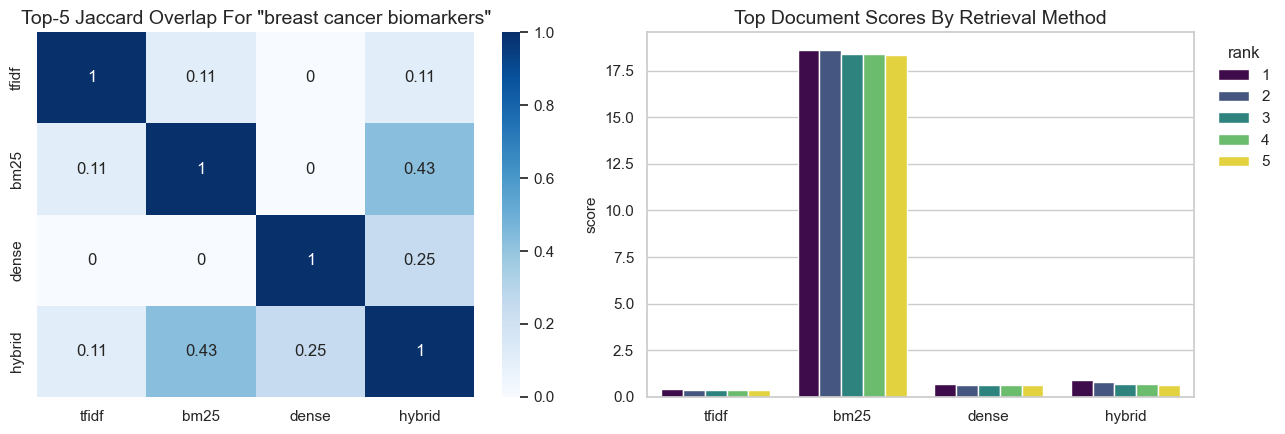

In [11]:
overlap_matrix = pd.DataFrame(0.0, index=demo_methods, columns=demo_methods)
for method in demo_methods:
    overlap_matrix.loc[method, method] = 1.0
for row in overlap_rows:
    overlap_matrix.loc[row['method_a'], row['method_b']] = row['jaccard']
    overlap_matrix.loc[row['method_b'], row['method_a']] = row['jaccard']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(overlap_matrix.astype(float), annot=True, cmap='Blues', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title(f'Top-5 Jaccard Overlap For "{demo_query}"')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

score_plot_df = demo_results_df.copy()
sns.barplot(data=score_plot_df, x='method', y='score', hue='rank', palette='viridis', ax=axes[1])
axes[1].set_title('Top Document Scores By Retrieval Method')
axes[1].set_xlabel('')
axes[1].set_ylabel('score')
axes[1].legend(title='rank', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Why These Plots Matter

The heatmap shows pairwise overlap across retrieval methods, while the score chart shows how strongly each method scored its top returned papers.

Together they show that methods are not merely renaming the same ranking; they are surfacing meaningfully different slices of the literature.

### Interpreting The Search Walkthrough

This is the first place where the project's central idea becomes concrete.

Even when the methods look at the same query over the same corpus, they do not behave identically:

- lexical methods reward exact overlap between query wording and document text,
- dense retrieval is freer to match semantically related phrasing,
- hybrid retrieval tries to keep lexical precision while still gaining some semantic flexibility.

The overlap table shows that retrieval method choice changes which biomedical evidence reaches the user, not just the score values attached to the same papers.


## App Feature Demo: Clustering And AI Polish

The BioSeek app does more than return ranked lists. It also supports:

- **topic grouping** through clustering, and
- an **AI polish layer** that offers rewrites and short retrieval explanations.

These make the app more useful as a demo and as an exploration interface.


### Why Diversity Matters

In biomedical search, users often need information from multiple perspectives, such as treatments, mechanisms, side effects, and clinical trials.

A method that retrieves only a narrow theme may appear precise, but can miss important aspects of the evidence landscape.

Thus, diversity is essential for comprehensive understanding, not just variety.

Silhouette score measures how well-separated clusters are. In biomedical datasets, moderate scores are expected because topics often overlap semantically.


### What This Output Shows

The next outputs demonstrate two app-side interpretation features built on top of retrieval.

The clustering table summarizes topic groups within the retrieved results, and the AI-polish tables show lightweight query rewrites and short explanations for why top documents matched.


In [12]:
# Generate clustering outputs for the hybrid retrieval demo query.
# This uses the backend clustering service; the CLI equivalent is scripts/cluster_retrieval_results.py.
cluster_output = search_service.clusters(
    query=demo_query,
    method="hybrid",
    dataset_name=demo_dataset,
    top_k=20,
    num_clusters=5,
    vector_space="tfidf",
)

# Summarize cluster labels, sizes, and representative documents for display.
cluster_summary_df = pd.DataFrame(
    [
        {
            "cluster_id": cluster.cluster_id,
            "cluster_size": cluster.cluster_size,
            "keywords": ", ".join(cluster.representative_keywords[:5]),
            "representative_title": cluster.representative_docs[0].metadata.get("title", "") if cluster.representative_docs else "",
        }
        for cluster in cluster_output.cluster_summaries
    ]
)

# The AI polish layer is a lightweight backend helper from backend/app/services/ai_polish_service.py.
# It is intentionally interpretive and does not change evaluation scores.
ai_polish_payload = ai_polish_service.polish(
    query=demo_query,
    method="hybrid",
    dataset_name=demo_dataset,
    top_k=3,
    refine_clusters=False,
    include_matches=True,
)

ai_matches_df = pd.DataFrame(ai_polish_payload["why_this_matched"])
ai_suggestions_df = pd.DataFrame(
    {
        "rewrite_suggestions": pd.Series(ai_polish_payload["rewrite_suggestions"]),
        "suggested_follow_up_queries": pd.Series(ai_polish_payload["suggested_follow_up_queries"]),
    }
)

display(cluster_summary_df)
display(ai_matches_df)
display(ai_suggestions_df)


,cluster_id,cluster_size,keywords,representative_title
0,0,1,"tnbc, ybx1, glycolysis, breast cancer, breast",Prognostic Value of a Glycolytic Signature and Its Regulation by Y-Box-Binding Protein 1 in Triple-Negative Breast C...
1,1,1,"breast, aa, breast cancer, cancer, stage",Differentially expressed transcripts and dysregulated signaling pathways and networks in African American breast can...
2,2,16,"breast, breast cancer, cancer, biomarkers, her2",PTPRT Could Be a Treatment Predictive and Prognostic Biomarker for Breast Cancer.
3,3,1,"hrd, cxcl10, database, geo database, tcga database",CXCL10 potentiates immune checkpoint blockade therapy in homologous recombination-deficient tumors.
4,4,1,"bone, bone metastasis, er, metastasis, mir 19a",Exosomal miR-19a and IBSP cooperate to induce osteolytic bone metastasis of estrogen receptor-positive breast cancer.


,pmid,title,explanation
0,34408238,Survival analysis in breast cancer using proteomic data from four independent datasets.,"shared query terms: biomarkers, breast, cancer; matched biomedical theme near MeSH term 'Aged'; appears in journal c..."
1,34567804,The Utility of SOX2 and AGR2 Biomarkers as Early Predictors of Tamoxifen Resistance in ER-Positive Breast Cancer Pat...,"shared query terms: biomarkers, breast, cancer; matched biomedical theme near MeSH term 'Antineoplastic Agents, Horm..."
2,34139239,"Elevated circRNAs circ_0000745, circ_0001531 and circ_0001640 in human whole blood: Potential novel diagnostic bioma...","shared query terms: biomarkers, breast, cancer; matched biomedical theme near MeSH term 'Biomarkers, Tumor'; appears..."


,rewrite_suggestions,suggested_follow_up_queries
0,breast cancer biomarkers pubmed review,breast cancer biomarkers biomarkers
1,NaN,breast cancer biomarkers side effects
2,NaN,breast cancer biomarkers randomized trial
3,NaN,breast cancer biomarkers clinical outcomes


### Visualizing Cluster Structure

We plot how retrieved documents are grouped into clusters:

- A **cluster size chart** showing how many documents fall into each cluster  
- A **theme chart** showing representative keywords for each cluster

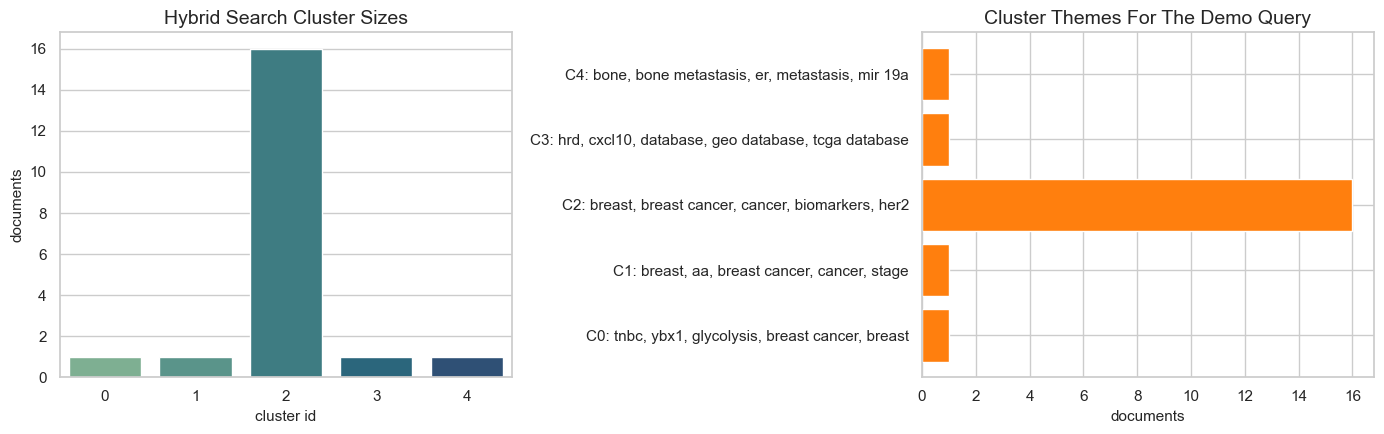

In [13]:
cluster_plot_df = cluster_summary_df.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=cluster_plot_df, x='cluster_id', y='cluster_size', palette='crest', ax=axes[0])
axes[0].set_title('Hybrid Search Cluster Sizes')
axes[0].set_xlabel('cluster id')
axes[0].set_ylabel('documents')

keyword_labels = [f"C{row.cluster_id}: {row.keywords}" for row in cluster_plot_df.itertuples()]
axes[1].barh(keyword_labels, cluster_plot_df['cluster_size'], color='#ff7f0e')
axes[1].set_title('Cluster Themes For The Demo Query')
axes[1].set_xlabel('documents')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


## Why These Plots Matters

These plots reveal how results are distributed across topics and what each cluster represents.

They make it easier to see whether retrieval produces focused themes or a mix of different concepts, beyond just ranked results.

### Why These Features Matter

The clustering output shows the **structure of the returned evidence**, not just its ranked order. That supports the project's claim that retrieval quality includes how the literature is organized and exposed.

The AI polish layer is intentionally lightweight. It does **not** affect benchmark scores. Its role is to just help the user interpret and refine the search experience inside the app. Thus this AI feature is just an additional feature primarily developed for UI UX of the app


## Benchmark Evaluation On The Unified Dataset

The live search walkthrough above uses the exploratory PubMed subset, which is what the app searches interactively.

The results below come from the **unified evaluation dataset**, where BioASQ questions and relevance judgments are joined to the curated PubMed subset using exact PMIDs.

These evaluation artifacts were generated by `scripts/evaluate_retrieval.py`, which computes Precision@5, Precision@10, Recall@10, MRR, nDCG@5, and nDCG@10 for each method across the surviving unified queries.

This is the section that answers the main performance question: **which retrieval method works best overall?**


## Evaluation Metrics

We use multiple metrics because no single measure fully captures retrieval quality:

* **Precision@k**: Proportion of relevant documents in the top-k results.
* **Recall@k**: Proportion of relevant documents retrieved from the total relevant set.
* **MRR (Mean Reciprocal Rank)**: Measures how early the first relevant result appears.
* **nDCG@k**: Evaluates ranking quality, giving higher importance to correctly ordering top results.

To analyze structure and diversity:

* **Cluster entropy**: Measures how spread results are across clusters.
* **Theme coverage**: Measures how many distinct biomedical topics are represented.

These metrics allow us to evaluate not only accuracy, but also how information is distributed.


### Quantitative Comparison Across Methods
This benchmark table is the main quantitative comparison across TF-IDF, BM25, dense, and hybrid retrieval.


In [14]:
metric_columns = [
    "precision_at_5",
    "precision_at_10",
    "recall_at_10",
    "mrr",
    "ndcg_at_5",
    "ndcg_at_10",
]

# Build the main benchmark table from the saved Stage 5 evaluation outputs
# created by scripts/evaluate_retrieval.py.
overall_metrics_df = summary_metrics.copy()
overall_metrics_df[metric_columns] = overall_metrics_df[metric_columns].round(4)
overall_metrics_df = overall_metrics_df.sort_values("ndcg_at_10", ascending=False).reset_index(drop=True)
overall_metrics_df.index = overall_metrics_df.index + 1
overall_metrics_df.index.name = "rank"
display(overall_metrics_df)

# Surface the saved narrative summary alongside the numeric results.
display(Markdown("**Narrative findings from the saved evaluation artifacts**"))
for key, text in summary_narrative.items():
    display(Markdown(f"- **{key.replace('_', ' ').title()}**: {text}"))


,method,precision_at_5,precision_at_10,recall_at_10,mrr,ndcg_at_5,ndcg_at_10
rank,,,,,,,
1,hybrid,0.5706,0.4291,0.7704,0.8868,0.8081,0.8145
2,bm25,0.5706,0.4270,0.7687,0.8781,0.8050,0.8101
3,tfidf,0.4569,0.3512,0.6049,0.7115,0.6128,0.6224
4,dense,0.4370,0.3280,0.5803,0.7309,0.6138,0.6144


**Narrative findings from the saved evaluation artifacts**

- **Best Overall**: HYBRID performs best overall on the unified dataset by average nDCG@10 (0.8145) and also leads or stays competitive on the other top-k metrics.

- **Where Lexical Is Better**: Lexical retrieval tends to be stronger when the BioASQ query wording directly overlaps with the terminology used in titles and abstracts, especially for explicit disease, treatment, and adverse-event phrases.

- **Where Dense Or Hybrid Helps**: Dense and hybrid retrieval are most useful when biomedical concepts are expressed with variant terminology, synonyms, abbreviations, or indirect phrasing. Hybrid retrieval is particularly valuable when semantic matching helps with terminology mismatch while lexical signals still anchor precision. Average semantic-family nDCG@10 is 0.7145 versus 0.7163 for the lexical family.

### Interpretation

Hybrid retrieval performs best overall, particularly in nDCG@10, indicating strong ranking quality.

BM25 performs competitively, highlighting the importance of exact biomedical terminology.

Dense retrieval improves recall but may introduce less precise matches, demonstrating the tradeoff between semantic flexibility and exact matching.


### Comparing Retrieval Performance

We visualize evaluation metrics across retrieval methods:

- A **multi-metric chart** to compare performance across all evaluation measures  
- A **ranking chart** to highlight final performance using nDCG@10

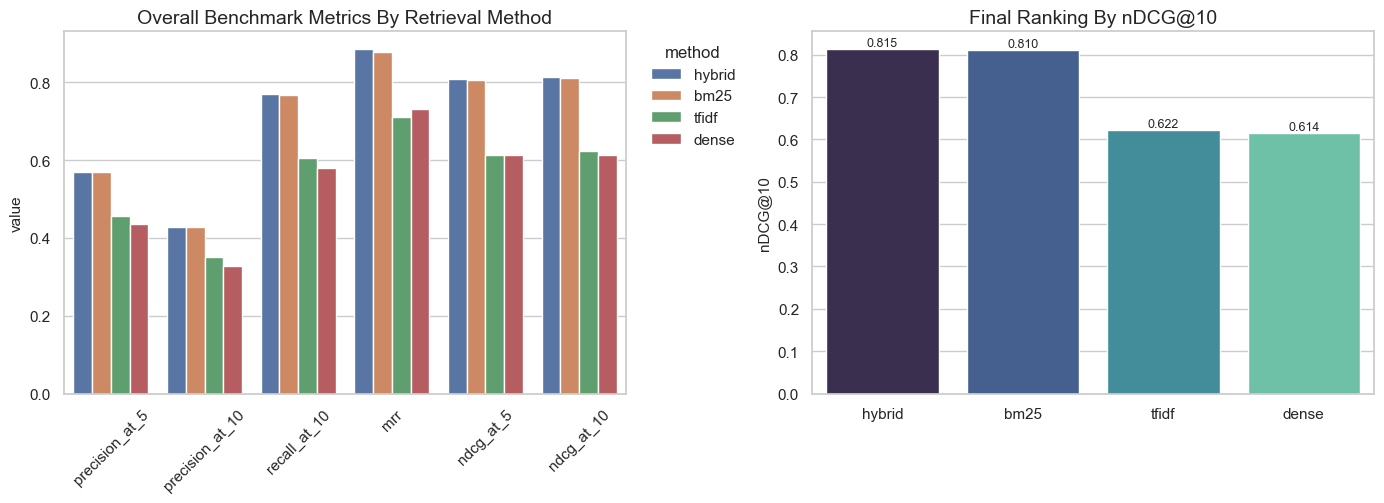

In [15]:
plot_metrics_df = overall_metrics_df.reset_index(drop=True).copy()
plot_metrics_long = plot_metrics_df.melt(id_vars='method', value_vars=metric_columns, var_name='metric', value_name='value')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(data=plot_metrics_long, x='metric', y='value', hue='method', ax=axes[0])
axes[0].set_title('Overall Benchmark Metrics By Retrieval Method')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('')
axes[0].legend(title='method', bbox_to_anchor=(1.02, 1), loc='upper left')

summary_rank_plot = plot_metrics_df[['method', 'ndcg_at_10']].sort_values('ndcg_at_10', ascending=False)
sns.barplot(data=summary_rank_plot, x='method', y='ndcg_at_10', palette='mako', ax=axes[1])
axes[1].set_title('Final Ranking By nDCG@10')
axes[1].set_xlabel('')
axes[1].set_ylabel('nDCG@10')
for idx, value in enumerate(summary_rank_plot['ndcg_at_10']):
    axes[1].text(idx, value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


### Why These Plots Matter

The left chart compares all evaluation metrics side by side, while the right chart isolates the final nDCG@10 ranking.

This makes it easier to see not only who wins overall, but also whether one method is strong for only one metric or consistently strong across several metrics.

### Main Result

The most important result of the project is that **hybrid retrieval is the strongest overall method** on the final unified benchmark.

In this project run, hybrid achieves the best overall **nDCG@10** while staying highly competitive on the other ranking metrics. BM25 remains extremely strong, which is useful because it shows that lexical retrieval is still hard to beat in biomedical search when terminology overlap is high.

Dense retrieval helps conceptually, but in this project it is not strong enough on its own to beat the best lexical or hybrid alternatives.

**Takeaway:** Hybrid retrieval provides the best overall ranking quality, while BM25 confirms that exact biomedical terminology remains highly effective.


## Query-Type Analysis

A single overall leaderboard is useful, but it can hide important behavior differences. BioSeek therefore breaks the benchmark into query buckets such as:

- exact terminology,
- synonym-heavy,
- treatment/intervention,
- outcome/effect,
- broad exploratory.

This section is based on outputs from `scripts/analyze_query_types.py`, while the notebook also uses `backend/app/services/query_service.py` to show how the same logic appears in the app for interactive examples.

This matters because retrieval method quality can depend heavily on query phrasing.


### Performance Breakdown Across Query Types

We break down evaluation by query type using three tables:

- A **pivot table** showing method performance per query bucket  
- A **winner table** identifying the best method for each bucket  
- A **sample query table** illustrating how queries are categorized


In [16]:
# Compare nDCG@10 across query buckets to expose method-specific strengths.
# These outputs come from scripts/analyze_query_types.py and its saved CSV/JSON artifacts.
bucket_pivot = (
    per_bucket_metrics_df
    .pivot(index="bucket", columns="method", values="ndcg_at_10")
    .round(4)
    .sort_index()
)
display(bucket_pivot)

bucket_winners_df = pd.DataFrame(
    [
        {
            "bucket": bucket_name,
            "num_queries": payload["num_queries"],
            "best_method_by_ndcg_at_10": payload["best_method_by_ndcg_at_10"],
        }
        for bucket_name, payload in bucket_summary["buckets"].items()
    ]
).sort_values("num_queries", ascending=False)
display(bucket_winners_df)

# Show how the app's featured queries map into the notebook's query taxonomy.
sample_query_buckets_df = pd.DataFrame(
    [
        {
            "query": query,
            "bucket_final": query_service.classify_query(query)[1],
            "rationale": query_service.classify_query(query)[2],
        }
        for query in frontend_shell["featuredQueries"]
    ]
)
display(sample_query_buckets_df)


method,bm25,dense,hybrid,tfidf
bucket,,,,
broad_exploratory,0.8006,0.6307,0.8167,0.6202
exact_terminology,0.8110,0.5573,0.8154,0.6162
outcome_effect,0.8693,0.7435,0.8798,0.6874
synonym_heavy,0.9018,0.5946,0.9092,0.7520
treatment_intervention,0.7810,0.6181,0.8024,0.5751


,bucket,num_queries,best_method_by_ndcg_at_10
4,broad_exploratory,2147,hybrid
0,exact_terminology,1709,hybrid
3,outcome_effect,480,hybrid
2,treatment_intervention,456,hybrid
1,synonym_heavy,43,hybrid


,query,bucket_final,rationale
0,heart attack,exact_terminology,"short, direct query with exact terminology emphasis"
1,myocardial infarction,exact_terminology,"short, direct query with exact terminology emphasis"
2,diabetes treatment,treatment_intervention,matched treatment/intervention vocabulary
3,drug adverse effects,treatment_intervention,matched treatment/intervention vocabulary
4,breast cancer biomarkers,exact_terminology,"short, direct query with exact terminology emphasis"


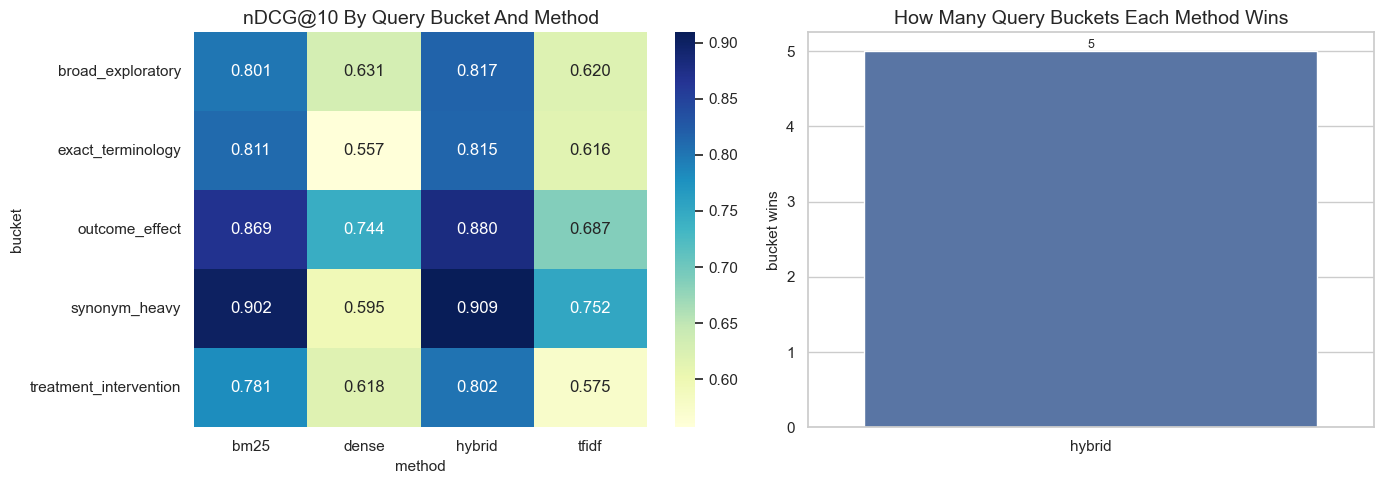

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(bucket_pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('nDCG@10 By Query Bucket And Method')
axes[0].set_xlabel('method')
axes[0].set_ylabel('bucket')

winner_counts = bucket_winners_df['best_method_by_ndcg_at_10'].value_counts().rename_axis('method').reset_index(name='num_buckets_won')
sns.barplot(data=winner_counts, x='method', y='num_buckets_won', palette='deep', ax=axes[1])
axes[1].set_title('How Many Query Buckets Each Method Wins')
axes[1].set_xlabel('')
axes[1].set_ylabel('bucket wins')
for idx, value in enumerate(winner_counts['num_buckets_won']):
    axes[1].text(idx, value, str(value), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


### Query-Type Takeaway

The query-type analysis strengthens the project's aim.

BioSeek is not simply saying that one method is globally best. It shows that retrieval behavior depends on query form. In the saved results, hybrid is the most consistently strong method across buckets, which is what we would want from a practical search interface.

**Takeaway:** Retrieval performance varies by query form, but hybrid remains the most consistently strong method across the different buckets.


## Structure Analysis

Relevance is one part of the main idea of BioSeek. But BioSeek also asks whether a method returns a broader or narrower picture of the literature.

The diversity analysis measures things like:

- how many global clusters are represented,
- how evenly results are distributed across those clusters,
- and how much thematic coverage each method achieves.

These saved outputs come from `scripts/analyze_diversity.py`, which clusters the global corpus and then measures how each method's top results are distributed across those clusters.


### Comparing Relevance and Diversity

We construct a summary table combining relevance and diversity metrics:

- Relevance metrics (Precision@10, nDCG@10)  
- Diversity metrics (clusters represented, entropy, theme coverage)

In [18]:
# Assemble the diversity summary table used for relevance-structure comparisons.
# This table is loaded from eval/results/unified/diversity/dense/method_level_diversity.csv,
# which was produced by scripts/analyze_diversity.py.
diversity_view_df = diversity_metrics_df.copy()
diversity_view_df[[
    "clusters_represented",
    "cluster_entropy",
    "theme_coverage",
    "precision_at_10",
    "ndcg_at_10",
]] = diversity_view_df[[
    "clusters_represented",
    "cluster_entropy",
    "theme_coverage",
    "precision_at_10",
    "ndcg_at_10",
]].round(4)
diversity_view_df = diversity_view_df.sort_values("ndcg_at_10", ascending=False)
display(diversity_view_df[[
    "method",
    "clusters_represented",
    "cluster_entropy",
    "theme_coverage",
    "precision_at_10",
    "ndcg_at_10",
]])

# Pair the table with the saved narrative interpretation from the evaluation artifacts.
display(Markdown("**Saved diversity narrative**"))
for key, text in diversity_payload["narrative"].items():
    display(Markdown(f"- **{key.replace('_', ' ').title()}**: {text}"))


,method,clusters_represented,cluster_entropy,theme_coverage,precision_at_10,ndcg_at_10
2,hybrid,3.9990,0.7451,18.1677,0.4338,0.8220
0,bm25,4.3067,0.7678,19.4534,0.4270,0.8101
3,tfidf,4.3394,0.7746,19.6176,0.3512,0.6224
1,dense,3.5617,0.7095,16.2521,0.3280,0.6144


**Saved diversity narrative**

- **Narrow But Precise**: HYBRID is the narrowest strong performer in this run, combining higher precision (P@10=0.4338) with lower spread than broader methods.

- **Broader Theme Coverage**: TFIDF covers the broadest themes in this run with average theme coverage 19.62 and cluster entropy 0.7746.

- **Hybrid Balance**: Hybrid shows precision@10=0.4338, nDCG@10=0.8220, cluster_entropy=0.7451, and theme_coverage=18.17, suggesting a balance between relevance and breadth.

- **Best Relevance Diversity Tradeoff**: HYBRID offers the strongest combined relevance/diversity profile in this run with nDCG@10=0.8220 and cluster entropy=0.7451.

#### Why This Matters

This table helps compare not just how well methods rank results, but how broadly they cover different topics.

It highlights the tradeoff between precision and diversity, and shows which method best balances both.

###  Visualizing Relevance–Diversity Tradeoff

We plot how retrieval methods balance relevance and diversity:

- A **scatter plot** comparing nDCG@10 with cluster entropy  
- A **bar chart** showing theme coverage for each method

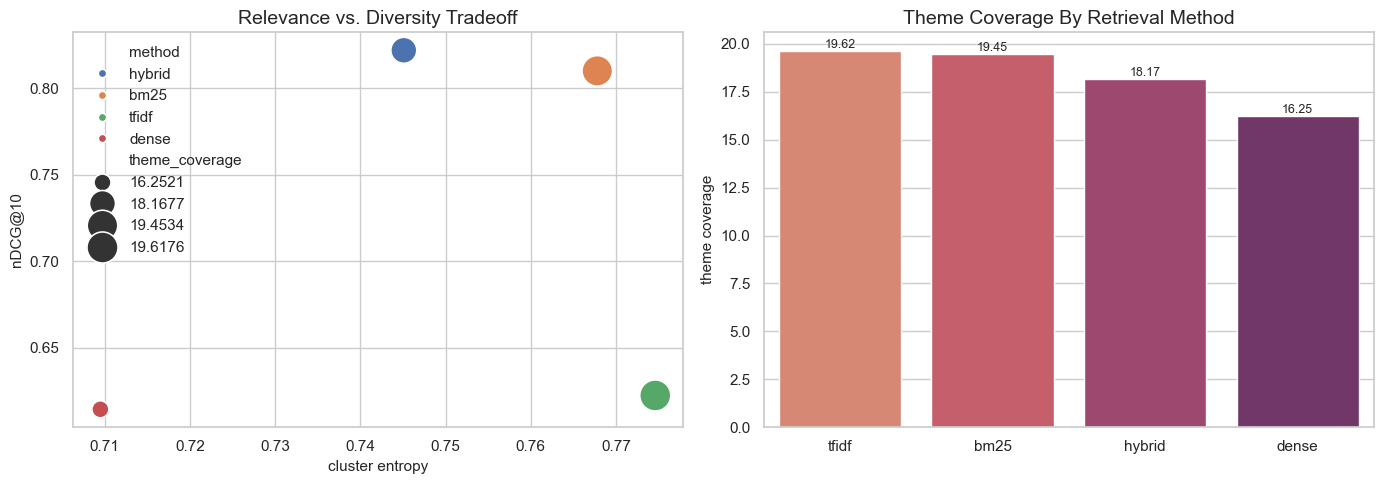

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=diversity_view_df,
    x='cluster_entropy',
    y='ndcg_at_10',
    hue='method',
    size='theme_coverage',
    sizes=(150, 500),
    ax=axes[0],
)
axes[0].set_title('Relevance vs. Diversity Tradeoff')
axes[0].set_xlabel('cluster entropy')
axes[0].set_ylabel('nDCG@10')

coverage_plot_df = diversity_view_df.sort_values('theme_coverage', ascending=False)
sns.barplot(data=coverage_plot_df, x='method', y='theme_coverage', palette='flare', ax=axes[1])
axes[1].set_title('Theme Coverage By Retrieval Method')
axes[1].set_xlabel('')
axes[1].set_ylabel('theme coverage')
for idx, value in enumerate(coverage_plot_df['theme_coverage']):
    axes[1].text(idx, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#### Why This Matters

These plots show how methods differ in balancing ranking quality and topic coverage.

They help identify whether higher relevance comes at the cost of diversity or if a method achieves both.

### Inspecting Best and Worst Case Queries

We extract a few example queries where the hybrid method performs best and worst, along with their evaluation scores.


In [20]:
hybrid_examples_df = pd.DataFrame(best_worst_payload["hybrid"]["best_queries"])[[
    "query_text", "query_type", "ndcg_at_10", "mrr", "precision_at_10"
]].head(3)
hybrid_failures_df = pd.DataFrame(best_worst_payload["hybrid"]["worst_queries"])[[
    "query_text", "query_type", "ndcg_at_10", "mrr", "precision_at_10"
]].head(3)

display(Markdown("**Examples where hybrid performs especially well**"))
display(hybrid_examples_df)
display(Markdown("**Examples where hybrid is weakest**"))
display(hybrid_failures_df)


**Examples where hybrid performs especially well**

,query_text,query_type,ndcg_at_10,mrr,precision_at_10
0,How functional connectivity of the default mode network changes in patients with disorders of consciousness?,summary,1.0,1.0,0.7
1,Which pituitary adenoma is common cause of infertility is women?,factoid,1.0,1.0,0.9
2,Albumin depletion is a common first step for proteomic analysis of CSF fluid. What is the advantage and disadvantage...,summary,1.0,1.0,0.7


**Examples where hybrid is weakest**

,query_text,query_type,ndcg_at_10,mrr,precision_at_10
0,Which are the main histone modifications associated with enhancers?,list,0.0,0.0,0.0
1,Is microRNA(miRNA) 30 involved in post-ischemic cardiac remodeling?,yesno,0.0,0.0,0.0
2,Is Mammaprint approved by the United States Food and Drug Administration?,yesno,0.0,0.0,0.0


### Diversity Takeaway

The diversity results support a nuanced conclusion:

- **TF-IDF** tends to cover broader thematic territory,
- **BM25** is extremely strong on lexical precision,
- **Dense retrieval** helps semantically but is weaker overall in this project,
- **Hybrid** offers the best balance between relevance and broader structure.

That balance is exactly why hybrid becomes the strongest final choice for the app's default narrative.

**Takeaway:** Hybrid offers the strongest overall balance between relevance and broader evidence structure, while TF-IDF contributes the widest thematic spread.


## Final Conclusions

BioSeek answers its research question with a clear result.

1. **Retrieval method choice materially changes what biomedical evidence is surfaced.**
2. **Hybrid retrieval is the strongest overall method in this project run.**
3. **BM25 remains a very strong baseline and shows the continued power of lexical matching in biomedical search.**
4. **Dense retrieval is useful conceptually, but by itself it is not the best final system here.**
5. **Relevance should not be the only lens. Diversity, structure, and query-type behavior reveal important differences that a single leaderboard would miss.**

This is the core story the web app also demonstrates and the benchmark analysis supports.


## Limitations

A few important limitations of this project are:

- The benchmark depends on the **coverage of the curated PubMed subset**. If a relevant PubMed paper is missing from that corpus, no retrieval method can recover it.
- The final unified benchmark is built with an **exact PMID join**, which improves evaluation quality but also reduces dataset size and therefore limits coverage.
- The **number of surviving evaluation queries and relevant judgments** is much smaller than the full BioASQ universe, so leaderboard differences should be interpreted carefully.
- The dense and clustering components are more computationally expensive than TF-IDF or BM25, so **scalability** becomes a practical concern if the corpus grows far beyond the current subset.
- Dense retrieval quality depends on the local sentence-transformer model and environment configuration.
- The AI polish layer is **not part of the benchmark** and should be treated as an additional user-experience feature rather than evidence that retrieval quality itself improved.


## Future Directions

If this project were extended further, the most useful next steps would be:

1. Scale the corpus from the curated subset toward a much larger PubMed slice so the retrieval comparison is tested under more realistic biomedical search volume.
2. Expand the evaluation set with more BioASQ-style questions and relevance judgments so the conclusions are less sensitive to a relatively small benchmark.
3. Tune hybrid fusion weights and candidate-pool sizes more systematically instead of keeping a single fixed fusion setting.
4. Continue the optional dense-adaptation experiment with a complete checked-in config and stronger biomedical positive/negative pair construction.
5. Evaluate diversification more directly, for example by measuring whether cluster-aware reranking helps users cover multiple biomedical subtopics without losing too much relevance.
6. Add human-centered evaluation, such as whether clinicians or students prefer the broader hybrid/diversified views when exploring treatments, biomarkers, or adverse effects.


## Reproducibility

To reproduce the full project pipeline from code rather than only reading saved artifacts:

1. Run `scripts/join_pubmed_bioasq.py` to create the unified BioASQ-PubMed benchmark tables.
2. Run `scripts/build_retrieval_indexes.py` to build TF-IDF, BM25, and dense indexes through the backend retrievers.
3. Run `scripts/evaluate_retrieval.py` to generate the benchmark metrics saved under `eval/results/unified/`.
4. Run `scripts/analyze_query_types.py` and `scripts/analyze_diversity.py` to produce the deeper analysis artifacts.
5. Optionally run `scripts/cluster_retrieval_results.py` or the FastAPI app to reproduce the interactive clustering behavior.
6. Execute this notebook in order to load those artifacts, call the same backend services, and narrate the final results.

**Code locations to inspect for this notebook:**

- Retrieval implementations: `backend/app/retrieval/*.py`
- App-facing services: `backend/app/services/*.py`
- Analysis scripts: `scripts/*.py`
- Project-level settings: `shared/config/settings.json`


## Screenshots of the Web Application

This appendix presents representative screenshots of the BioSeek web application interface.
Each view corresponds to one of the interactive components discussed earlier in the notebook.


### Search Interface

The search interface supports direct biomedical query entry and displays ranked retrieval results from the underlying backend services.
These screenshots illustrate the main landing page and a representative search interaction.

<div style="display:flex; gap:10px; margin-top:8px; margin-bottom:18px;">
  <img src="Images/Bioseek_Main_Page.jpeg" width="48%"/>
  <img src="Images/Search 2.jpeg" width="48%"/>
</div>


### Compare View

The compare view places retrieval methods side by side so that differences in ranking behavior can be inspected directly.
This interface supports qualitative comparison across lexical, dense, and hybrid retrieval outputs.

<div style="display:flex; gap:10px; margin-top:8px; margin-bottom:18px;">
  <img src="Images/Compare_Bioseek.jpeg" width="48%"/>
  <img src="Images/Compare2.jpeg" width="48%"/>
</div>


### Explore (Clustering)

The explore view emphasizes clustering and thematic organization of retrieved biomedical documents.
These screenshots show how the application groups related papers into interpretable topic clusters.

<div style="display:flex; gap:10px; margin-top:8px; margin-bottom:18px;">
  <img src="Images/Cluster_Bioseek.jpeg" width="48%"/>
  <img src="Images/Cluster2.jpeg" width="48%"/>
</div>


### Evaluation Dashboard

The evaluation dashboard summarizes benchmark metrics and provides a compact view of comparative method performance.

<div style="display:flex; gap:10px; margin-top:8px; margin-bottom:18px;">
  <img src="Images/Evaluation_Bioseek.jpeg" width="48%"/>
  <img src="Images/Eval2.jpeg" width="48%"/>
</div>


### AI-Assisted Refinement

The AI-assisted refinement view provides lightweight support for query reformulation and interpretation of retrieved evidence.
It is intended as an interface enhancement rather than a component of the benchmark evaluation itself.

<div style="display:flex; gap:10px; margin-top:8px; margin-bottom:18px;">
  <img src="Images/AI_Refinement.jpeg" width="48%"/>
</div>
